In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import zscore

In [3]:
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'
print(df.shape)
df.head()

(4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [4]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['MONTH'] = df['Date'].dt.month
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,MONTH
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,Ethiopia,2026-03-31,3


In [5]:
# Check for missing values and duplicates(-999 is NASA's sentinel value for missing or out-of-range data.)
df = df.replace(-999, np.nan)
print("Number of duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows found: 0


No duplicate rows were found and removed using drop_duplicates().
Duplicates were exact row-level repeats across all columns (no partial column-specific duplicates detected).

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation of Descriptive Statistics

The dataset contains 4,108 observations spanning the years 2015 to 2026, indicating a long-term climate record.

The temperature variables (T2M, T2M_MAX, T2M_MIN) show moderate variation. The mean temperature (T2M ≈ 16.07°C) is close to the median (16.04°C), suggesting a relatively symmetric distribution. The range between minimum (10.03°C) and maximum (21.53°C) indicates noticeable seasonal temperature variation.

Relative humidity (RH2M) has a mean of approximately 68.4%, with values ranging from 14.42% to 91.93%. This wide range suggests strong seasonal or weather-driven fluctuations in atmospheric moisture.

Precipitation (PRECTOTCORR) is highly skewed, with a median of 0.82 but a maximum of 82.3, indicating occasional extreme rainfall events while most days experience little to no precipitation.

Wind speed (WS2M) and maximum wind speed (WS2M_MAX) show moderate variability, with generally low average wind conditions.

Surface pressure (PS) is very stable, with minimal variation across the dataset, indicating consistent atmospheric pressure conditions.

Specific humidity (QV2M) shows moderate variation, reflecting changes in moisture content over time.

Overall, the dataset reflects typical climate behavior with strong seasonal variability in temperature, humidity, and precipitation, while atmospheric pressure remains relatively stable.

In [7]:
df.isna().sum() 
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
MONTH          0.0
dtype: float64


In [8]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_rows = outliers.any(axis=1).sum()
print("Number of rows with extreme values (|Z| > 3):", outlier_rows)

Number of rows with extreme values (|Z| > 3): 132


#Number of rows with extreme values (|Z| > 3): 132
### Z-Score Outlier Analysis
Rows with absolute Z-scores greater than 3 were flagged as potential outliers, indicating unusually extreme weather conditions compared to the dataset distribution.

The analysis identified 132 rows containing at least one extreme value. These outliers may correspond to rare weather events such as heatwaves, heavy rainfall, or unusually strong winds.

Such extreme values are important in climate analysis and should not be automatically removed, as they may represent meaningful environmental phenomena rather than data errors.

In [9]:
# Forward-fill weather-related columns
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
threshold = int(0.7 * df.shape[1])  # keep rows with at least 70% non-null values
df = df.dropna(thresh=threshold)


### Missing Value Handling

Missing values were handled using a combination of forward-fill imputation and row removal.

Forward-fill was applied to key weather variables (temperature, precipitation, humidity, and wind speed) to preserve temporal continuity in the dataset. This method assumes that short gaps in measurements can be reasonably approximated using the most recent valid observation.

Additionally, rows with more than 30% missing values were removed to ensure data quality and reliability. This prevents heavily incomplete records from skewing analysis.

In this dataset, no missing values remained after initial preprocessing, so these steps served as a precautionary measure to ensure robustness.

In [10]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

#Time series Analysis

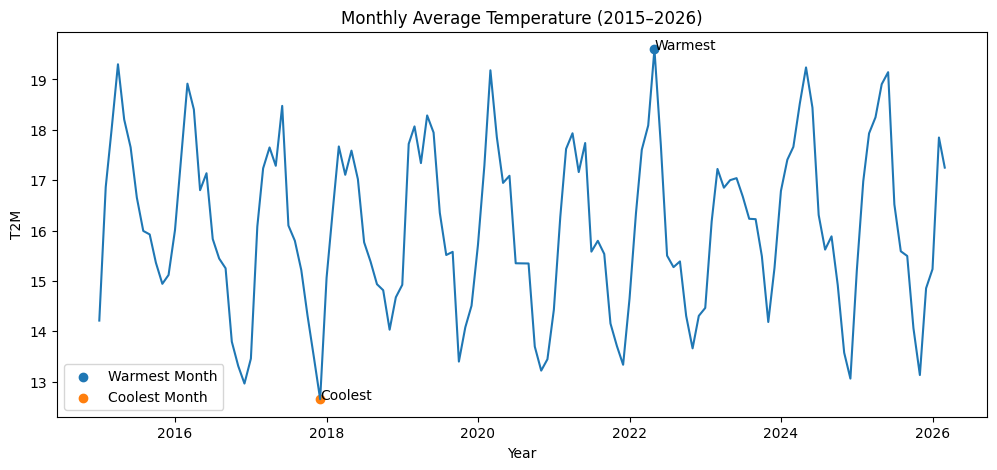

In [11]:
mon_AT2M = df.groupby(["YEAR", "MONTH"])["T2M"].mean().reset_index()

mon_AT2M["Date"] = pd.to_datetime(
    mon_AT2M["YEAR"].astype(str) + "-" + mon_AT2M["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.plot(mon_AT2M["Date"], mon_AT2M["T2M"])

# warmest / coolest
warmest = mon_AT2M.loc[mon_AT2M["T2M"].idxmax()]
coolest = mon_AT2M.loc[mon_AT2M["T2M"].idxmin()]

plt.scatter(warmest["Date"], warmest["T2M"], label="Warmest Month")
plt.scatter(coolest["Date"], coolest["T2M"], label="Coolest Month")

plt.annotate("Warmest", (warmest["Date"], warmest["T2M"]))
plt.annotate("Coolest", (coolest["Date"], coolest["T2M"]))

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("T2M")
plt.legend()
plt.show()

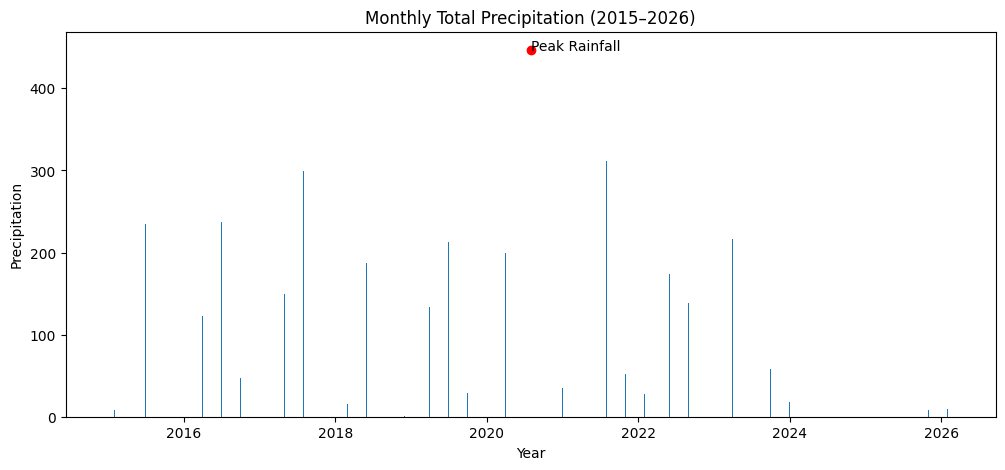

In [12]:

mon_rain = df.groupby(["YEAR", "MONTH"])["PRECTOTCORR"].sum().reset_index()

mon_rain["Date"] = pd.to_datetime(
    mon_rain["YEAR"].astype(str) + "-" + mon_rain["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.bar(mon_rain["Date"], mon_rain["PRECTOTCORR"])

peak = mon_rain.loc[mon_rain["PRECTOTCORR"].idxmax()]

plt.scatter(peak["Date"], peak["PRECTOTCORR"], color="red")
plt.annotate("Peak Rainfall", (peak["Date"], peak["PRECTOTCORR"]))

plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.show()

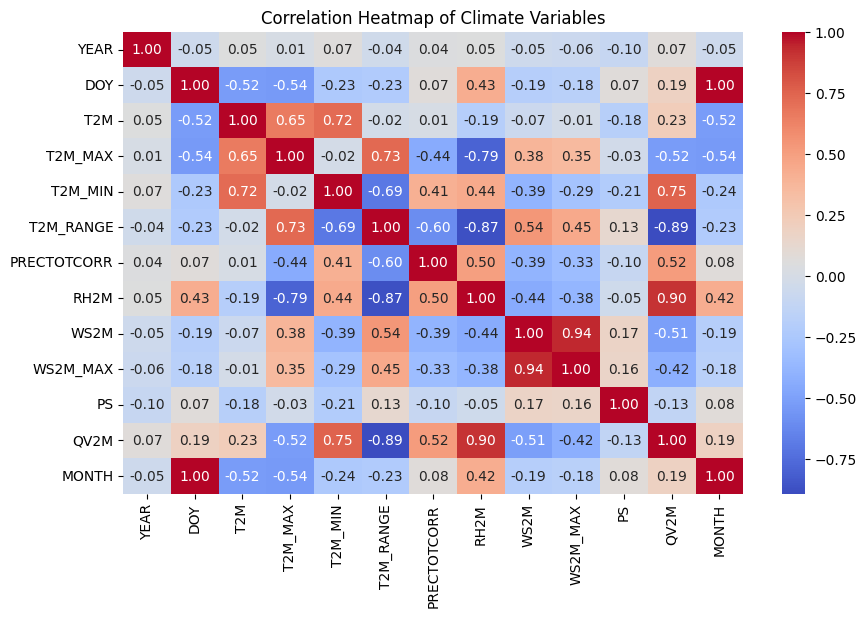

In [13]:

###Correlation heatmap
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Climate Variables")
plt.show()

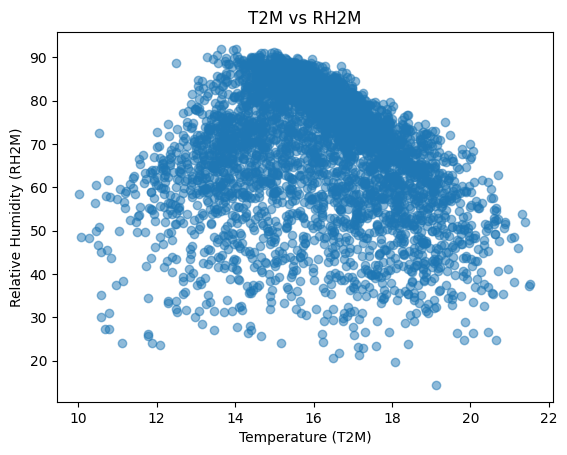

In [14]:
###Scatter plot of T2M vs RH2M

plt.figure()

plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

plt.show()

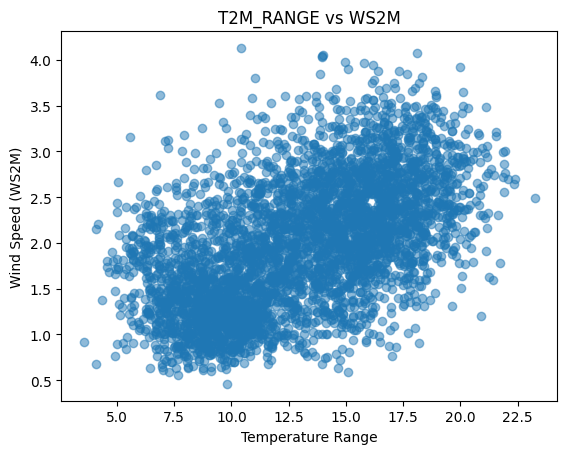

In [15]:
###Scatter plot of T2M_RANGE vs WS2M

plt.figure()

plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.show()

In [16]:
###Identify the strongest correlations (positive and negative)
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.head(10))

DOY        MONTH        0.996557
MONTH      DOY          0.996557
WS2M_MAX   WS2M         0.940826
WS2M       WS2M_MAX     0.940826
RH2M       QV2M         0.904901
QV2M       RH2M         0.904901
T2M_MIN    QV2M         0.753414
QV2M       T2M_MIN      0.753414
T2M_MAX    T2M_RANGE    0.731151
T2M_RANGE  T2M_MAX      0.731151
dtype: float64
